In [1]:
import scanpy as sc 
import os

notebookPath = os.path.dirname(os.path.dirname(os.getcwd()))

bdata = sc.read(os.path.join(notebookPath, "data", "integratedFiltered.h5ad"))
bdata.obs_names_make_unique()

In [2]:
bdata.obs["controles"] = [
    "controle" if i.startswith("CTH") else "estudo"
    for i in bdata.obs["library_id"]
]

bdata.obs["classificacao"] = [
    "PB" if i.startswith("PB")
    else "controle" if i.startswith("CTH")
    else "MB"
    for i in bdata.obs["library_id"]
]

bdata.obs["estimulo"] = [
    "nao estimulado" if i.endswith("NS") else "estimulado"
    for i in bdata.obs["library_id"]
]

In [3]:
print(bdata.obs["classificacao"].unique())
print(bdata.obs["controles"].unique())
print(bdata.obs["estimulo"].unique())

['controle' 'MB' 'PB']
['controle' 'estudo']
['estimulado' 'nao estimulado']


In [4]:
print('---------------------')
print(bdata.obs["classificacao"].value_counts())
print('---------------------')
print('---------------------')
print(bdata.obs["controles"].value_counts())
print('---------------------')
print('---------------------')
print(bdata.obs["estimulo"].value_counts())
print('---------------------')


---------------------
classificacao
PB          15628
controle    14559
MB           4782
Name: count, dtype: int64
---------------------
---------------------
controles
estudo      20410
controle    14559
Name: count, dtype: int64
---------------------
---------------------
estimulo
estimulado        20862
nao estimulado    14107
Name: count, dtype: int64
---------------------


In [5]:
from copy import deepcopy
bdata.layers["counts"] = deepcopy(bdata.X)

In [6]:
import spatools as st
bdata = st.tl.translate_anndata_genes(adata=bdata)

10 input query terms found dup hits:	[('ENSG00000291072', 2), ('ENSG00000234162', 2), ('ENSG00000227110', 2), ('ENSG00000243620', 2), ('E
214 input query terms found no hit:	['ENSG00000238009', 'ENSG00000291215', 'ENSG00000290784', 'ENSG00000236948', 'ENSG00000226849', 'ENS


In [7]:
print(f"ENSG genes: {len([i for i in bdata.var_names if not i.startswith('ENSG')])}")
print(f"symbol genes: {len([i for i in bdata.var_names if i.startswith('ENSG')])}")

ENSG genes: 15446
symbol genes: 2315


In [8]:
bdata.var

,gene_ids,gene_symbol
ENSG00000238009,ENSG00000238009,ENSG00000238009
ENSG00000241860,ENSG00000241860,ENSG00000241860
ENSG00000290385,ENSG00000290385,ENSG00000290385
ENSG00000291215,ENSG00000291215,ENSG00000291215
LINC01409,ENSG00000237491,LINC01409
...,...,...
MT-ND6,ENSG00000198695,MT-ND6
MT-CYB,ENSG00000198727,MT-CYB
MAFIP,ENSG00000274847,MAFIP
ENSG00000273748,ENSG00000273748,ENSG00000273748


In [9]:
import scanpy as sc

# genes mitocondriais
bdata.var["mt"] = bdata.var_names.str.startswith("MT-")

# genes ribossomais
bdata.var["rps"] = bdata.var_names.str.startswith("RPS")
bdata.var["rpl"] = bdata.var_names.str.startswith("RPL")

# calcular QC metrics
sc.pp.calculate_qc_metrics(
    bdata,
    qc_vars=["mt", "rps", "rpl"],
    inplace=True
)

# Benchmark de Integração (scib)

Métodos testados: **Harmony**, **scVI**, **Scanorama**, **BBKNN**, **scGEN**, **Seurat v3 CCA**, **Seurat v3 RPCA**, **ComBat** e **MNN**.

> **Nota sobre métodos extras:** além dos solicitados, incluímos **ComBat** (robusto para correção de batch linear, muito usado em dados de citometria/bulk adaptados para scRNA) e **MNN** (Mutual Nearest Neighbours, baseline sólido e interpretável). Ambos complementam bem o painel, especialmente para comparar métodos lineares vs não-lineares no seu contexto de PB/MB/controle.

In [10]:
import scanpy as sc
import numpy as np
import pandas as pd
import scib
import warnings
from copy import deepcopy
warnings.filterwarnings("ignore")

adata_bench = deepcopy(bdata)

# ──────────────────────────────────────────────────────────────
# 1. Recriar objeto limpo a partir dos counts brutos
#    (necessário: scib exige counts originais em .layers["counts"])
# ──────────────────────────────────────────────────────────────
adata_bench = sc.AnnData(
    X=bdata.layers["counts"].copy(),
    obs=bdata.obs[["library_id", "controles", "classificacao", "estimulo"]].copy(),
    var=bdata.var[["mt", "rps", "rpl"]].copy()
)

adata_bench.layers["counts"] = adata_bench.X

# Normalização padrão + log1p para seleção de HVGs
sc.pp.normalize_total(adata_bench, target_sum=1e4)
sc.pp.log1p(adata_bench)
adata_bench.raw = adata_bench  # guardar expressão completa

# Seleção de HVGs por batch (seurat_v3 nos counts)
sc.pp.highly_variable_genes(
    adata_bench,
    n_top_genes=5000,
    batch_key="library_id",
    flavor="seurat_v3",
    subset=True
)

# PCA no dado não integrado (baseline)
sc.pp.scale(adata_bench)
sc.tl.pca(adata_bench, n_comps=50, svd_solver="arpack")

# Parâmetros globais do benchmark
BATCH_KEY  = "library_id"
LABEL_KEY  = "classificacao"   # PB / MB / controle
N_NEIGHBORS = 15

print(adata_bench)


AnnData object with n_obs × n_vars = 34969 × 5000
    obs: 'library_id', 'controles', 'classificacao', 'estimulo'
    var: 'mt', 'rps', 'rpl', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'


2026-05-28 14:28:21,783 - harmonypy - INFO - Running Harmony
2026-05-28 14:28:21,784 - harmonypy - INFO -   Parameters:
2026-05-28 14:28:21,784 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-28 14:28:21,785 - harmonypy - INFO -     max_iter_kmeans: 4
2026-05-28 14:28:21,785 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-05-28 14:28:21,785 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-05-28 14:28:21,785 - harmonypy - INFO -     nclust: 100
2026-05-28 14:28:21,785 - harmonypy - INFO -     block_size: 0.05
2026-05-28 14:28:21,786 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-05-28 14:28:21,786 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-05-28 14:28:21,786 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-28 14:28:21,786 - harmonypy - INFO -     verbose: True
2026-05-28 14:28:21,786 - harmonypy - INFO -     random_state: 0
2026-05-28 14:28:21,787 - harmonypy - INFO -   Data: 50 PCs × 34969 cells
2026-05-28 14:

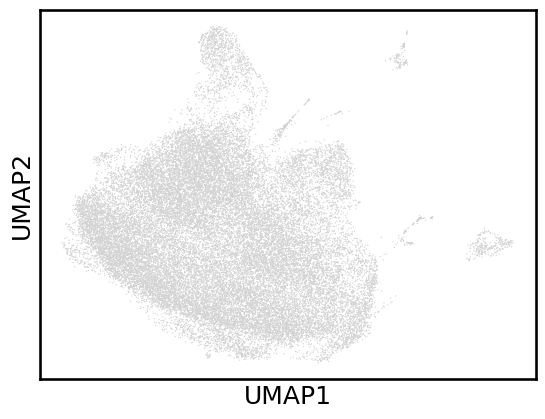

Harmony OK


In [ ]:
import harmonypy as hm
import numpy as np

adata_harmony = adata_bench.copy()

ho = hm.run_harmony(
    np.asarray(adata_harmony.obsm["X_pca"]),
    adata_harmony.obs,
    BATCH_KEY
)

adata_harmony.obsm["X_emb_harmony"] = np.asarray(ho.Z_corr)

sc.pp.neighbors(
    adata_harmony,
    use_rep="X_emb_harmony",
    n_neighbors=N_NEIGHBORS
)

sc.tl.umap(adata_harmony)
sc.tl.leiden(adata_harmony, resolution=0.5, key_added="leiden_0.5")

print("Harmony OK")

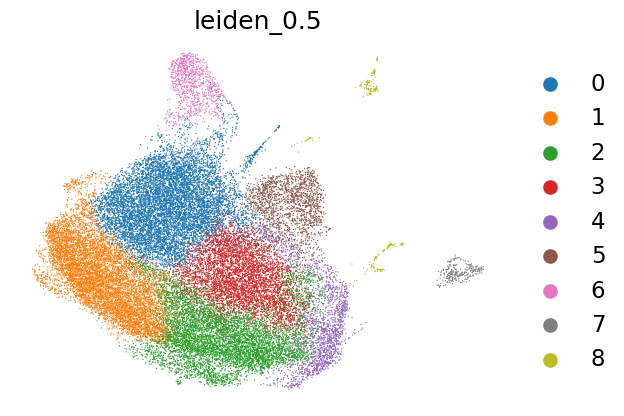

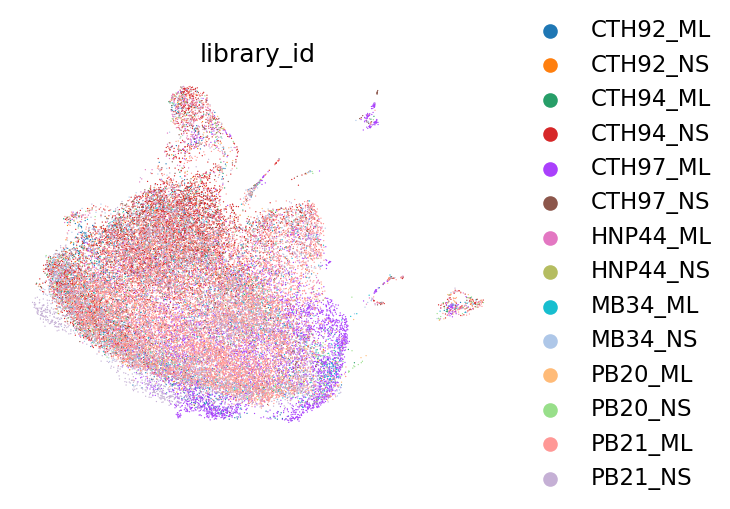

In [12]:
sc.pl.umap(adata_harmony, color = "leiden_0.5", frameon=False)
sc.pl.umap(adata_harmony, color = "library_id", frameon=False)

In [13]:
import os

caminho = os.path.dirname(os.path.dirname(os.getcwd()))

adata_harmony.write_h5ad(filename=os.path.join(caminho, "data", "adata_harmony.h5ad"))

In [14]:
# ──────────────────────────────────────────────────────────────
# 3. scVI  (usa counts brutos, não HVG-scaled)
# ──────────────────────────────────────────────────────────────
import scvi

adata_scvi = adata_bench.copy()

scvi.model.SCVI.setup_anndata(
    adata_scvi,
    batch_key=BATCH_KEY,
    layer="counts"
)
model_scvi = scvi.model.SCVI(
    adata_scvi
)
model_scvi.train()

adata_scvi.obsm["X_emb_scVI"] = model_scvi.get_latent_representation()
sc.pp.neighbors(adata_scvi, use_rep="X_emb_scVI", n_neighbors=N_NEIGHBORS)
sc.tl.umap(adata_scvi)
sc.tl.leiden(adata_scvi, resolution=0.5, key_added="leiden")
print("scVI: OK")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 229/229: 100%|██████████| 229/229 [05:44<00:00,  1.50s/it, v_num=1, train_loss=1.15e+3]

`Trainer.fit` stopped: `max_epochs=229` reached.


Epoch 229/229: 100%|██████████| 229/229 [05:44<00:00,  1.50s/it, v_num=1, train_loss=1.15e+3]
scVI: OK


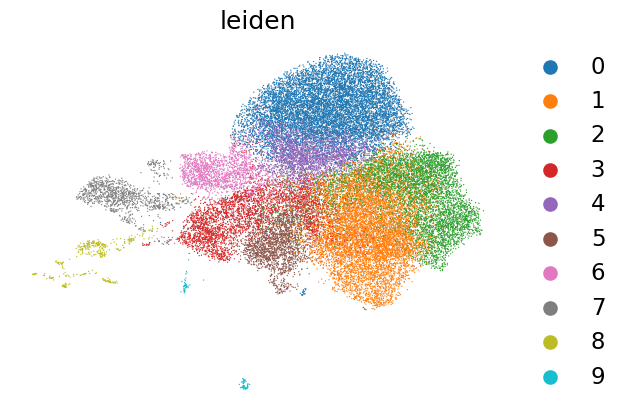

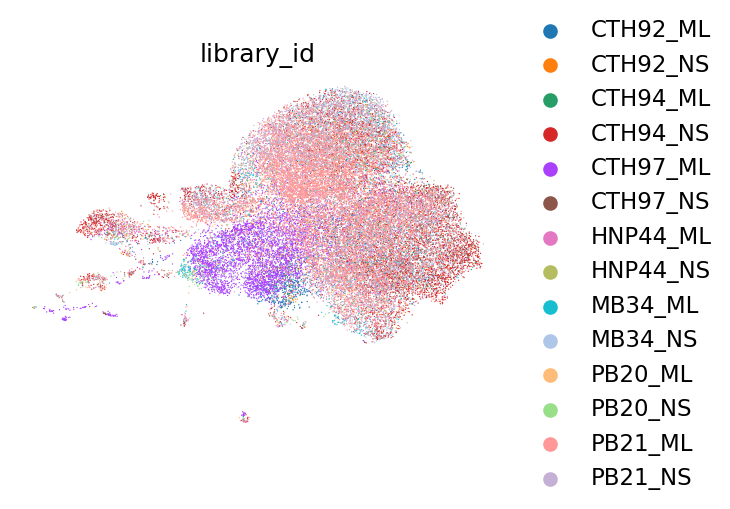

In [17]:
sc.pl.umap(adata_scvi, color = "leiden", frameon=False)
sc.pl.umap(adata_scvi, color = "library_id", frameon=False)

In [15]:
adata_scvi.write_h5ad("/mnt/SATA/singleCellTaru/data/adata_scvi.h5ad")

In [ ]:
# ──────────────────────────────────────────────────────────────
# 4. Scanorama
# ──────────────────────────────────────────────────────────────
adata_scanorama = adata_bench.copy()
sc.external.pp.scanorama_integrate(
    adata_scanorama,
    key=BATCH_KEY,
    basis="X_pca",
    adjusted_basis="X_emb_scanorama",
    batch_size=2000,
    verbose=1
)
sc.pp.neighbors(adata_scanorama, use_rep="X_emb_scanorama", n_neighbors=N_NEIGHBORS)
sc.tl.umap(adata_scanorama)
sc.tl.leiden(adata_scanorama, resolution=0.5, key_added="leiden")
print("Scanorama: OK")


[[0.         0.62438424 0.6252505  0.24426981 0.1146038  0.01394422
  0.50429646 0.03409091 0.30944625 0.04518664 0.15701416 0.05940594
  0.12442698 0.00327439]
 [0.         0.         0.38546798 0.78817734 0.05788177 0.09359606
  0.32635468 0.13636364 0.20738328 0.14408867 0.14285714 0.12211221
  0.2044335  0.0726601 ]
 [0.         0.         0.         0.55911824 0.11022044 0.06012024
  0.64729459 0.02272727 0.10621242 0.12024048 0.19238477 0.06813627
  0.36472946 0.01803607]
 [0.         0.         0.         0.         0.0086362  0.53054449
  0.36895811 0.57954545 0.13246471 0.33176347 0.16087516 0.21947195
  0.31684059 0.11047139]
 [0.         0.         0.         0.         0.         0.18791501
  0.09452202 0.         0.12486428 0.01360544 0.12483912 0.10561056
  0.25144943 0.04960275]
 [0.         0.         0.         0.         0.         0.
  0.14741036 0.65909091 0.04249668 0.25498008 0.0952381  0.16171617
  0.54316069 0.23705179]
 [0.         0.         0.         0.     

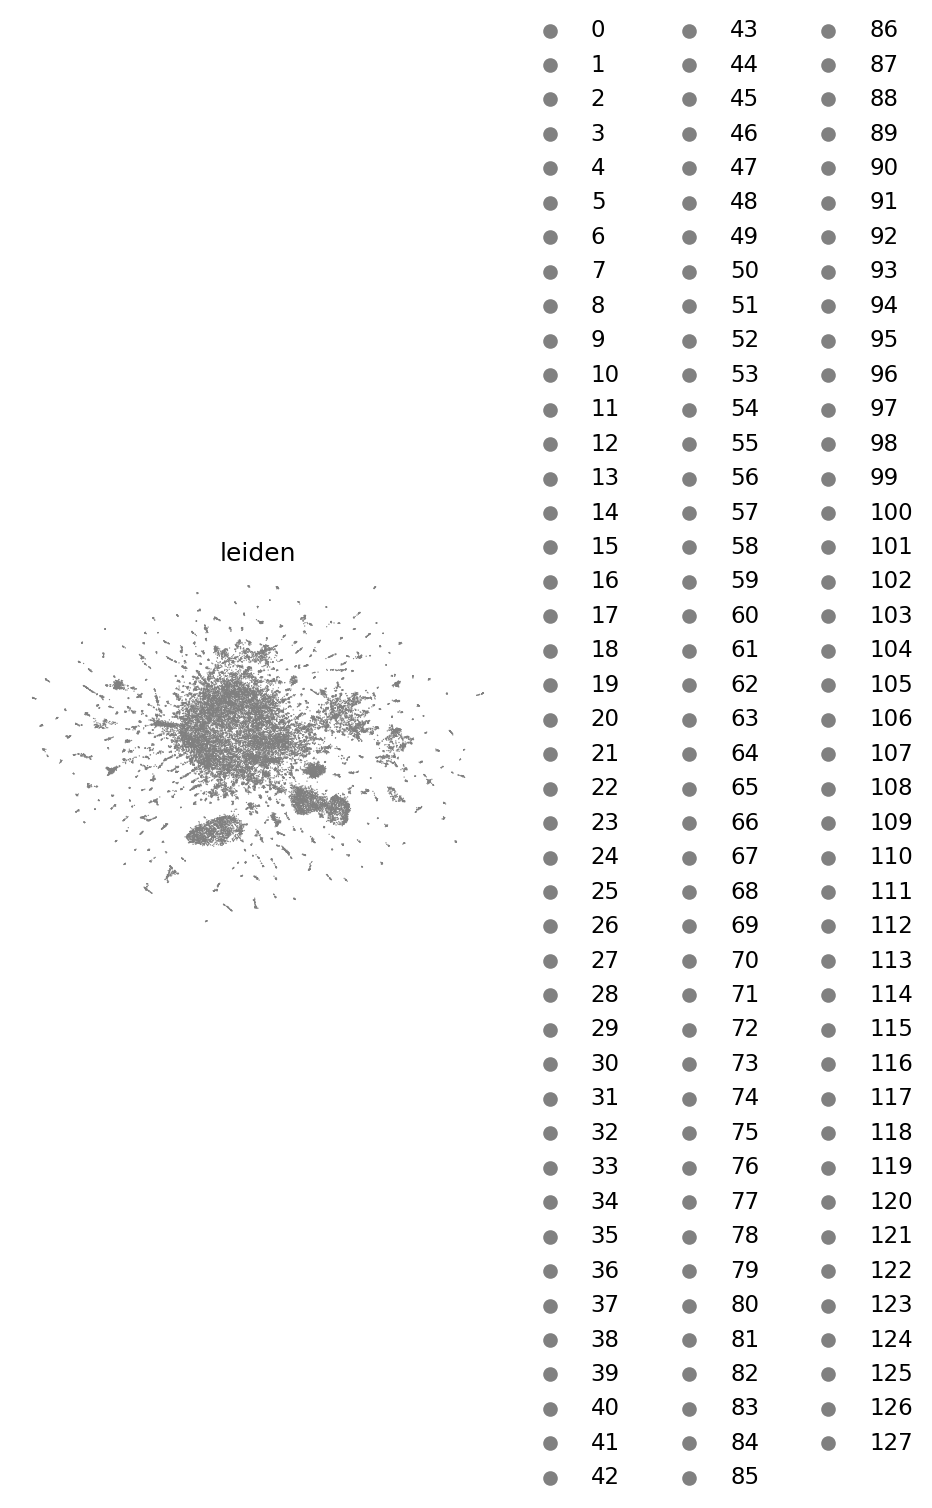

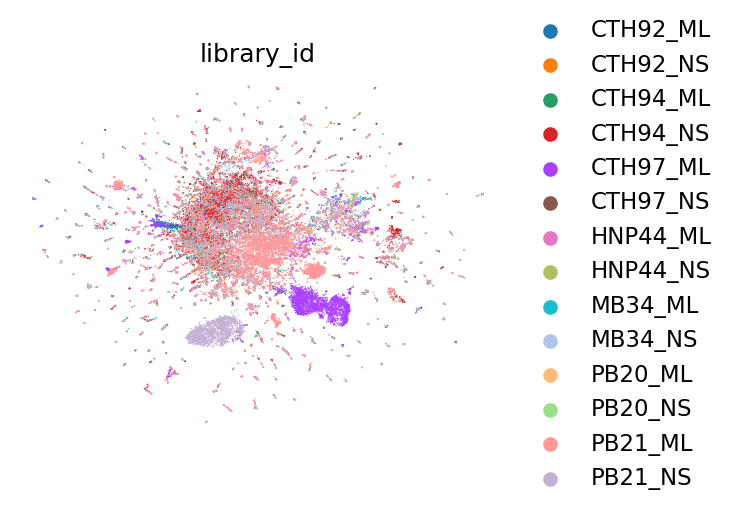

In [25]:
sc.pl.umap(adata_scanorama, color = "leiden", frameon=False)
sc.pl.umap(adata_scanorama, color = "library_id", frameon=False)

In [26]:
# ──────────────────────────────────────────────────────────────
# 5. BBKNN  (corrige o grafo de vizinhos, não o embedding)
# ──────────────────────────────────────────────────────────────
adata_bbknn = adata_bench.copy()
sc.external.pp.bbknn(
    adata_bbknn,
    batch_key=BATCH_KEY,
    n_pcs=50
)
sc.tl.umap(adata_bbknn)
sc.tl.leiden(adata_bbknn, resolution=0.5, key_added="leiden")
# BBKNN não gera embedding próprio; usa PCA corrigido como representação
adata_bbknn.obsm["X_emb_bbknn"] = adata_bbknn.obsm["X_pca"]
print("BBKNN: OK")


ImportError: Please install bbknn: `pip install bbknn`.